In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn import metrics
import seaborn as sns

In [34]:
df = pd.read_excel('../data/dzRf.xlsx')

# Исследование данных

In [35]:
print(f'Количество наблюдений: {df.shape[0]}')
print(f'Количество атрибутов: {df.shape[1]}')

Количество наблюдений: 1952
Количество атрибутов: 21


In [30]:
df.head()

,book_tod,book_dow,book_category,book_staff,last_category,last_staff,last_day_services,last_receipt_tot,last_dow,last_tod,...,last_prod_flag,last_cumrev,last_cumbook,last_cumstyle,last_cumcolor,last_cumprod,last_cumcancel,last_cumnoshow,noshow,recency
0,afternoon,Wednesday,STYLE,JJ,NaN,NaN,0,0.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,morning,Wednesday,COLOR,JOANNE,NaN,NaN,0,0.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,NaN,Wednesday,STYLE,JJ,COLOR,JOANNE,2,262.0,Wednesday,morning,...,1,262,2,1,1,2,0,0,0,35
3,afternoon,Thursday,STYLE,KELLY,NaN,NaN,0,0.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,evening,Saturday,STYLE,KELLY,STYLE,KELLY,1,35.0,Thursday,afternoon,...,0,35,1,1,0,0,0,0,0,9


In [36]:
# статистика по данным
description = df.describe(include='all')
description.to_excel('../data/description.xlsx', index=False)
description


,book_tod,book_dow,book_category,book_staff,last_category,last_staff,last_day_services,last_receipt_tot,last_dow,last_tod,...,last_prod_flag,last_cumrev,last_cumbook,last_cumstyle,last_cumcolor,last_cumprod,last_cumcancel,last_cumnoshow,noshow,recency
count,1717,1952,1952,1952,1003,1003,1952.000000,1952.000000,1003,858,...,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000
unique,3,7,3,7,3,7,NaN,NaN,7,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,afternoon,Thursday,STYLE,JJ,STYLE,JJ,NaN,NaN,Thursday,afternoon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,735,417,1531,722,728,355,NaN,NaN,220,321,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.545082,35.782679,NaN,NaN,...,0.114242,111.258197,1.906762,1.520492,0.325307,0.487193,0.280225,0.422643,0.114754,14.402152
std,NaN,NaN,NaN,NaN,NaN,NaN,0.658514,59.371877,NaN,NaN,...,0.318186,207.927702,3.315854,2.756585,0.827646,1.261275,0.853646,1.319786,0.318807,21.079495
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,60.000000,NaN,NaN,...,0.000000,132.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000


In [37]:
df.isnull().sum()

book_tod              235
book_dow                0
book_category           0
book_staff              0
last_category         949
last_staff            949
last_day_services       0
last_receipt_tot        0
last_dow              949
last_tod             1094
last_noshow             0
last_prod_flag          0
last_cumrev             0
last_cumbook            0
last_cumstyle           0
last_cumcolor           0
last_cumprod            0
last_cumcancel          0
last_cumnoshow          0
noshow                  0
recency                 0
dtype: int64

Количество категорий в которых есть пропуски 5. К ним относятся book_tod, book_dow, last_category, last_staff, last_dow, last_tod. Категория в которой больше всего пропусков - last_tod. Поскольку все атрибуты с пропусками категориальные, попробуем не заполнять пустые значения. Сразу заменим фиктивными атибутами.

In [38]:
# преобразуем категориальные перемеенные в фиктивные переменные
df = pd.get_dummies(df)

In [39]:
df.isnull().sum()

last_day_services      0
last_receipt_tot       0
last_noshow            0
last_prod_flag         0
last_cumrev            0
last_cumbook           0
last_cumstyle          0
last_cumcolor          0
last_cumprod           0
last_cumcancel         0
last_cumnoshow         0
noshow                 0
recency                0
book_tod_afternoon     0
book_tod_evening       0
book_tod_morning       0
book_dow_Friday        0
book_dow_Monday        0
book_dow_Saturday      0
book_dow_Sunday        0
book_dow_Thursday      0
book_dow_Tuesday       0
book_dow_Wednesday     0
book_category_COLOR    0
book_category_MISC     0
book_category_STYLE    0
book_staff_BECKY       0
book_staff_HOUSE       0
book_staff_JJ          0
book_staff_JOANNE      0
book_staff_KELLY       0
book_staff_SINEAD      0
book_staff_TANYA       0
last_category_COLOR    0
last_category_MISC     0
last_category_STYLE    0
last_staff_BECKY       0
last_staff_HOUSE       0
last_staff_JJ          0
last_staff_JOANNE      0


In [40]:
# посмотрим на данные после обработки
df.describe(include='all')

,last_day_services,last_receipt_tot,last_noshow,last_prod_flag,last_cumrev,last_cumbook,last_cumstyle,last_cumcolor,last_cumprod,last_cumcancel,...,last_dow_Friday,last_dow_Monday,last_dow_Saturday,last_dow_Sunday,last_dow_Thursday,last_dow_Tuesday,last_dow_Wednesday,last_tod_afternoon,last_tod_evening,last_tod_morning
count,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,...,1952,1952,1952,1952,1952,1952,1952,1952,1952,1952
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1734,1951,1779,1921,1732,1752,1792,1631,1732,1635
mean,0.545082,35.782679,0.076332,0.114242,111.258197,1.906762,1.520492,0.325307,0.487193,0.280225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.658514,59.371877,0.265597,0.318186,207.927702,3.315854,2.756585,0.827646,1.261275,0.853646,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,60.000000,0.000000,0.000000,132.000000,2.000000,2.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:

# посмотрим на корреляцию между атрибутами
corr = df.corr()
corr.to_excel("../data/correlations.xlsx")

In [42]:
# нижний треугольник матрицы
triangle = corr.abs().where(np.tril(np.ones(corr.shape), k=-1).astype(np.bool))

print("Самая сильная корреляция:")
print(triangle.stack().sort_values(ascending=False)[:10])

Самая сильная корреляция:
last_cumstyle        last_cumbook           0.971779
last_cumbook         last_cumrev            0.946657
last_cumstyle        last_cumrev            0.942458
book_category_STYLE  book_category_COLOR    0.886694
last_cumnoshow       last_cumstyle          0.810319
last_cumprod         last_cumcolor          0.803109
last_staff_JOANNE    last_category_COLOR    0.782214
book_staff_JOANNE    book_category_COLOR    0.772077
last_cumnoshow       last_cumbook           0.766798
                     last_cumrev            0.764871
dtype: float64


In [43]:
# уберем лишние столбцы
to_drop = ['last_cumbook', 'last_cumstyle', 'book_category_COLOR']
print("Убираем столбцы: ", to_drop)
df = df.drop(to_drop, axis=1)

Убираем столбцы:  ['last_cumbook', 'last_cumstyle', 'book_category_COLOR']


In [44]:
df.shape

(1952, 50)

In [45]:
# разделим данные на атибуты и то что нужно предсказать
Y = df.noshow
X = df.drop('noshow', axis=1)

количество не пришедших на прием менее 250 (из общего количества 1952 это составляет 13 %)

# Обучение классификатора

In [46]:
# Разделим данные на тестовую и тренировочную выборки
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3,stratify=Y, random_state=47)

In [47]:
# тренируем модель

clf = RandomForestClassifier(random_state=47, n_jobs=-1, n_estimators=100, class_weight='balanced_subsample')

In [48]:
filename = 'rf_model.sav'

In [49]:
clf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1,
                       random_state=47)

In [50]:
# проверяем модель по умолчанию
y_pred = clf.predict(X_test)
print(f"Результат на тестовых данных (модель по умолчанию): {100*metrics.balanced_accuracy_score(y_test, y_pred):.3f}")

Результат на тестовых данных (модель по умолчанию): 62.710


In [51]:
# подборка гиперпараметров
param_distributions = {"max_features": list(range(1,X.shape[1])), "max_depth": list(range(3, 30))}

In [52]:
randomized_search = RandomizedSearchCV(clf, param_distributions=param_distributions, n_iter=60, cv=5, scoring="balanced_accuracy", n_jobs=-1, random_state=47)
randomized_search.fit(X_train, y_train)

model = randomized_search.best_estimator_

print("Оптимальные параметры: %s, оценка на учебных данных: %0.2f" % (randomized_search.best_params_, randomized_search.best_score_))


Оптимальные параметры: {'max_features': 21, 'max_depth': 4}, оценка на учебных данных: 0.84


In [53]:
# сохрани учебную модель
pickle.dump(model, open(filename, 'wb'))

In [54]:
# потестируем модель
model = pickle.load(open(filename, 'rb'))
y_pred = model.predict(X_test)

In [55]:
print("Результат на тестовых данных: %f" % (100*metrics.balanced_accuracy_score(y_test, y_pred)))

Результат на тестовых данных: 77.826187


Результат улучшился с 62% до 78%

In [56]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

In [57]:
print("Матрица неточностей:")
print(cnf_matrix)

Матрица неточностей:
[[467  52]
 [ 23  44]]


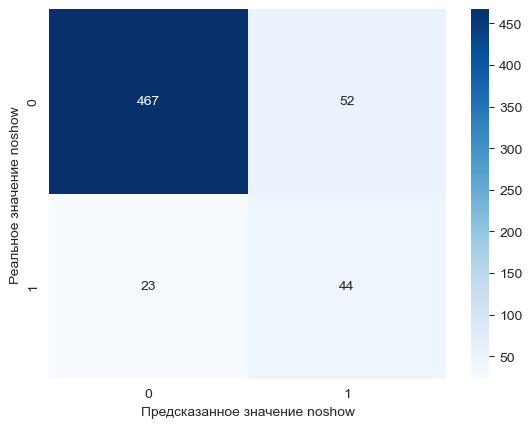

In [58]:
sns.heatmap(cnf_matrix, annot=True, cmap='Blues', fmt='g')
plt.ylabel('Реальное значение noshow')
plt.xlabel('Предсказанное значение noshow')
plt.show()